In [17]:
import numpy as np
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt
from PIL import Image

In [18]:
# img = plt.imread("barbara_gray.bmp")
img_pil = Image.open("lena.bmp")
print(img_pil.size, img_pil.format, img_pil.mode)
img = np.array(img_pil)
print(img[0:4,0:4])
# Image._show(img)

height, width = img.shape[0], img.shape[1]
# plt.imshow(img, cmap='gray')
# print(img.dtype)
P = 10
u1 = 4 
v1 = 5 
u2 = 5 
v2 = 4 # coefficients for embedding (4,5), (5,4)

(512, 512) BMP RGB
[[[193 111  74]
  [198 116  79]
  [195 113  76]
  [195 111  75]]

 [[196 114  77]
  [197 115  78]
  [194 112  75]
  [197 113  77]]

 [[199 115  78]
  [192 107  76]
  [200 117  77]
  [197 113  79]]

 [[200 116  80]
  [193 109  72]
  [200 116  82]
  [198 114  78]]]


In [19]:
def dct8x8(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

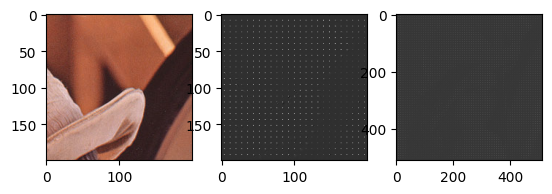

In [20]:
dct_image = np.zeros((height, width))
for i in range(0, height, 8):
    for j in range(0, width, 8):
        block = img[i:i+8, j:j+8, 0]
        dct_image[i:i+8, j:j+8] = dct8x8(block)

plt.subplot(1, 3, 1)
plt.imshow(img[0:200, 300:500], cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(dct_image[0:200, 300:500], cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(dct_image, cmap="gray")

## Embedding message

In [21]:
class LFSRGenerator:
    def __init__(self, seed, bits=16, taps = None):
        self.state = seed & ((1 << bits) - 1)
        self.bits = bits
        self.mask = (1 << bits) - 1
        # primitive polynome x^16 + x^14 + x^13 + x^11 + 1
        if taps == None:
            self.taps = [12, 6, 4, 1]#829
        else:
            self.taps = taps
        self.original_state = self.state

    def reset(self):
        self.state = self.original_state
    
    def next_bit(self):
        output = self.state & 1
        feedback = 0
        for tap in self.taps:
            feedback ^= (self.state >> (tap -1)) & 1

        self.state = (self.state << 1) | (feedback)# << (self.bits -1))
        self.state = self.state & self.mask
        # return output

    def get_bits(self, count):
        return [self.next_bit() for _ in range(count)]
    
    def get_int(self):
        self.next_bit()
        return self.state
        
lfsr = LFSRGenerator(seed=0xFD2A, bits=12)
# print(lfsr.state)
# index = lfsr.get_int()
# print(index)
# print(lfsr.state)

    # print(lfsr.state)


In [22]:
data = np.zeros(2**12)
for i in range(2**12):
    data[i] = lfsr.get_int()
    if i % 200 == 0:
        print(i)

0
200
400
600
800
1000
1200
1400
1600
1800
2000
2200
2400
2600
2800
3000
3200
3400
3600
3800
4000


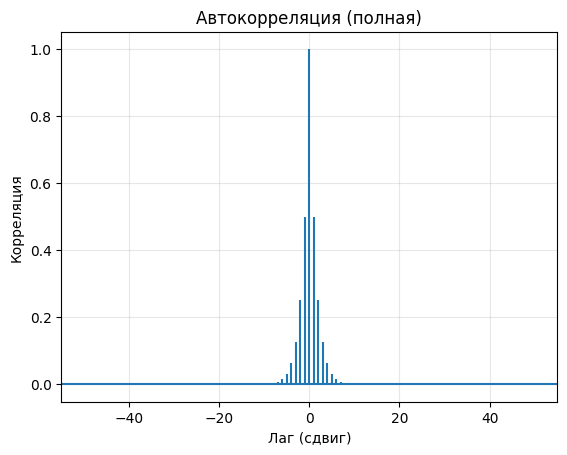

In [23]:
# Встроенная функция автокорреляции matplotlib
# Она сразу показывает и отрицательные, и положительные лаги
plt.acorr(data - np.mean(data), maxlags=50, normed=True)
plt.title('Автокорреляция (полная)')
plt.xlabel('Лаг (сдвиг)')
plt.ylabel('Корреляция')
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
def adjust_coeffs(block, bit):

    k1 = block[u1, v1]
    k2 = block[u2, v2]
    # print(k1, k2, end='\n')
    # if bit == 1 |k1| >= |k2| + P
    # if bit == 0 |k2| >= |k1| + P
    if(bit == 1):
        if abs(k1) >= abs(k2) + P:
            return block
        if abs(k1) + abs(k2) == 0:
            new_k1 = P+1
            new_k2 = 1
        else:
            avg = (abs(k1) + abs(k2))/2
            new_abs_k1 = avg + P/2
            new_abs_k2 = avg - P/2

            new_k1 = new_abs_k1 * np.sign(k1) if k1 != 0 else new_abs_k1
            new_k2 = new_abs_k2 * np.sign(k2) if k2 != 0 else new_abs_k2

            if abs(new_k1) < abs(new_k2) + P:
                new_k1 = (abs(new_k2) + P)*np.sign(new_k1)
    else:
        if abs(k2) >= abs(k1) + P:
            return block
        if abs(k1) + abs(k2) == 0:
            new_k1 = 1
            new_k2 = P + 1
        else:
            avg = (abs(k1) + abs(k2))/2
            new_abs_k1 = avg - P/2
            new_abs_k2 = avg + P/2

            new_k1 = new_abs_k1 * np.sign(k1) if k1 != 0 else new_abs_k1
            new_k2 = new_abs_k2 * np.sign(k2) if k2 != 0 else new_abs_k2

            if abs(new_k2) < abs(new_k1) + P:
                new_k2 = (abs(new_k1) + P)*np.sign(new_k2)
    # print(new_k1, new_k2)
    block[u1, v1] = new_k1
    block[u2, v2] = new_k2
    # print(block[u1, v1])
    # print(block[u2, v2])
    return block

In [25]:
message = "BUIVID"
binary_message = ''.join(format(ord(char), '08b') for char in message)
message_len = len(binary_message)
print(binary_message)
print(message_len)

binary_message += '00000000'
bit_index = 0

lfsr.reset()

for i in range(len(binary_message)):
    block_index = lfsr.get_int()
    row = int(block_index // (dct_image.shape[0]/8))
    col = int(block_index % (dct_image.shape[1]/8))
    print(row, col)
    block = dct_image[row*8:(row+1)*8, col*8:(col+1)*8]
    current_bit = int(binary_message[bit_index])
    print(block[u1, v1], block[u2, v2])
    dct_image[row*8:(row+1)*8, col*8:(col+1)*8] = adjust_coeffs(block, current_bit)
    bit_index += 1
    print(block[u1, v1], block[u2, v2])
# for i in range(0, height, 8):
#     for j in range(0, width, 8):
#         if bit_index >= len(binary_message):
#             break
#         block_index = lfsr.get_int()
#         # block = dct_image[i:i+8,j:j+8]
#         current_bit = int(binary_message[bit_index])
#         # block = adjust_coeffs(block, current_bit)
#         # np.set_printoptions(precision=1)
#         print(bit_index)
#         # print("1 ", block)
#         dct_image[i:i+8, j:j+8] = adjust_coeffs(block, current_bit)
#         print(block[u1, v1], block[u2, v2])
#         # print("2 ",dct_image[i:i+8, j:j+8])
#         bit_index += 1


010000100101010101001001010101100100100101000100
48
41 21
7.042245170902515 12.650728535513391
4.846486853207953 14.846486853207953
18 42
6.411217068856463 1.6028659222839003
10.992958504429819 -0.9929585044298186
37 20
-2.6463318826296915 2.9403784682541794
2.2066448245580643 12.206644824558065
10 41
4.010247969429052 4.065881777406695
-0.9619351265821265 10.961935126582127
21 19
1.902872258498666 8.940057393098158
0.42146482579841216 10.421464825798413
42 39
0.21854915482674508 2.052619456461749
-3.864415694355753 13.864415694355753
21 15
-1.1846255912534 6.503724154736748
-11.155825127004926 -1.1558251270049258
42 30
-0.25839078961105766 1.4550070252843237
4.143301092552309 14.14330109255231
20 60
2.0617458528513533 -1.7711360245821466
-3.08355906128325 -13.08355906128325
41 56
0.3691283994679193 0.19358224498197157
14.718644677775055 -4.718644677775055
19 49
1.1459817332923241 -3.596725196301924
-2.6286465352028756 -12.628646535202876
39 34
0.6985209997542083 0.13889255825490027
14

[193 111  74]


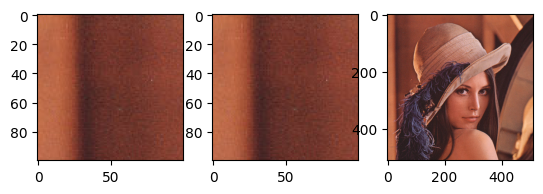

In [26]:
# stego_image = np.zeros_like(img)
stego_image = np.copy(img)
for i in range(0, height, 8):
    for j in range(0, width, 8):
        block = dct_image[i:i+8, j:j+8]
        stego_image[i:i+8, j:j+8, 0] = idct(idct(block.T, norm='ortho').T, norm='ortho')
print(stego_image[0,0])
stego_pil = Image.fromarray(stego_image)
stego_pil.save('stego_image.bmp')
# plt.imsave("stego_image.bmp", stego_image, cmap="gray" )
plt.subplot(1, 3, 1)
plt.imshow(img[0:100, 0:100])
plt.subplot(1, 3, 2)
plt.imshow(stego_image[0:100, 0:100])
plt.subplot(1, 3, 3)
plt.imshow(stego_image)

## Extracting message

In [27]:
# stego_image = plt.imread("stego_image.bmp")
stego_pil = Image.open("stego_image.bmp")
stego_image = np.array(stego_pil)
print(stego_image[0,0])
extracted_bits = []
bytes_array = []
lfsr.reset()
byte = 1
while(byte != 0):
    for i in range(8):
        block_index = lfsr.get_int()
        row = int(block_index // (stego_image.shape[0]/8))
        col = int(block_index % (stego_image.shape[1]/8))
        print(row, col)
        block = stego_image[row*8:(row+1)*8, col*8:(col+1)*8, 0]
        block = dct8x8(block)
        k1 = abs(block[u1, v1])
        k2 = abs(block[u2, v2])
        print(k1, k2)
        if k1 >= k2 + P:
            bit = 1
        elif k2 >= k1 + P:
            bit = 0
        else:
            # Если условие не выполняется четко, используем простое сравнение
            bit = 1 if k1 >= k2 else 0 
        extracted_bits.append(bit)
    
    byte = 0
    for bit in extracted_bits:
        byte = (byte << 1) | bit
    print(byte)
    bytes_array.append(byte)
    extracted_bits.clear()
# for i in range(0, height, 8):
#     for j in range(0, width, 8):
#         block = stego_image[i:i+8, j:j+8]
#         block = dct8x8(block)
#         k1 = abs(block[u1, v1])
#         k2 = abs(block[u2, v2])
#         print(k1, k2)
#         if k1 >= k2 + P:
#             bit = 1
#         elif k2 >= k1 + P:
#             bit = 0
#         else:
#             # Если условие не выполняется четко, используем простое сравнение
#             bit = 1 if k1 >= k2 else 0
#         print(bit)
#         extracted_bits.append(bit)
# print(extracted_bits)
# bytes_array = []
# for i in range(0, len(extracted_bits), 8):
#     if i+8 > len(extracted_bits):
#         break
#     byte_bits = extracted_bits[i:i+8]
#     byte = 0
#     for bit in byte_bits:
#         byte = (byte << 1) | bit
#     bytes_array.append(byte)
message_dec = ''
for byte in bytes_array:
    if byte == 0:
        break
    message_dec += chr(byte)

print(message_dec)


[193 111  74]
41 21
4.764540022928004 14.928433683487901
18 42
11.26059626541032 1.0589281040463165
37 20
2.6934399541257816 12.460230323440806
10 41
0.7415860661167419 11.005300983176129
21 19
0.3748328894758438 11.217762541072664
42 39
3.643341218461199 14.054025382476853
21 15
11.067421191865602 1.0535365860103412
42 30
3.950259545007423 14.293565552831582
66
20 60
3.0530319281200162 13.115629304566838
41 56
14.444390550603565 4.75334211257995
19 49
2.421939739390781 12.3906895606374
39 34
14.427023189559318 5.004455538903796
15 4
4.312729717740926 14.125998153886181
30 8
14.092779352811329 4.1034306700136405
60 17
5.036138772361394 14.931071584726308
56 34
14.919981164552631 5.485367937873057
85
49 4
2.867536236480356 11.970717008244625
34 9
11.1851615654511 0.5733084137491824
4 19
0.2415995051006008 10.61336828047534
8 39
2.17083920184145 12.031921436969219
17 14
11.321416090227313 0.6855880882584814
34 29
1.1346974674584533 13.360969358569564
4 59
0.44984456836893894 11.546303410